# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Кутельмах Євген Петрович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Кутельмах Євген Петрович, ШІ-34, варіант 8
ваш потік:                   P>5
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
table = pd.read_excel(ФАЙЛ)
display(table.dtypes)
display(table.head())

Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Функція read_excel читає заголовки з першого рядка, який в наданому файлі майже незаповнений.
Більшість типів стовпців зазначено як object, тобто будь-що, лише декілька стовпців мають числовий тип.
Більшість з них повністю пуста, Nan, і pandas конвертує це в float64

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)
print('Розмір:', RAW.size)
RAW[:30]

Розмір: 231232


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Таблиць всього 3. Перша - 1:14, Друга - 16:19, Третя - 24:31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
metadata = pd.read_excel(ФАЙЛ, header=None, nrows=24)
for col in metadata.columns:
    lines = metadata[col].dropna().tolist()
    
    if len(lines) > 0:
        print(f"\n--- Текст зі стовпця {col} ---")
        for line in lines:
            print(line)


--- Текст зі стовпця 1 ---
ftp://ftp.swpc.noaa.gov/pub/lists/particle/
:Data_list: 20170901_Gs_part_5m.txt
:Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
# Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
# 
# Label: P > 1 = Particles at >1 Mev
# Label: P > 5 = Particles at >5 Mev
# Label: P >10 = Particles at >10 Mev
# Label: P >30 = Particles at >30 Mev
# Label: P >50 = Particles at >50 Mev
# Label: P>100 = Particles at >100 Mev
# Label: E>0.8 = Electrons at >0.8 Mev
# Label: E>2.0 = Electrons at >2.0 Mev
# Label: E>4.0 = Electrons at >4.0 Mev
# Units: Particles = Protons/cm2-s-sr
# Units: Electrons = Electrons/cm2-s-sr
# Source: GOES-15
# Location: W135
# Missing data: -1.00e+05
5-minute  GOES-15 Solar Particle and Electron Flux

--- Текст зі стовпця 5 ---
Modified

--- Текст зі стовпця 6 ---
Seconds

--- Текст зі стовпця 16 ---
ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Product: Dai

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | ftp://ftp.swpc.noaa.gov/pub/lists/particle/ | Protons/cm2-s-sr, Electrons/cm2-s-sr |
| B | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt | Month, Date, Radio Flux 10.7 |
| C | http://umtof.umd.edu/pm/crn/ | Proton speed [km/sec], Proton density [protons per cubic centimeter], Measurement time (Year, Month, Day of Month, Day of Year, Hour, Minute, Second) |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = pd.read_excel(ФАЙЛ, header=25, usecols="B:O").apply(pd.to_numeric, errors='coerce')
B = pd.read_excel(ФАЙЛ, header=26, usecols="Q:T").apply(pd.to_numeric, errors='coerce').dropna()
C = pd.read_excel(ФАЙЛ, header=26, usecols="Y:AF").apply(pd.to_numeric, errors='coerce').dropna()

B = B.rename(columns={B.columns[0]: 'Year'})
C = C.rename(columns={C.columns[0]: 'Ind1', C.columns[1]: 'Ind2'})

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['ts'] = pd.to_datetime({
    'year': A['# YR'], 
    'month': A['MO'], 
    'day': A['DA'], 
    'hour': A['HHMM'] // 100,
    'minute': A['HHMM'] % 100
})

B['ts'] = pd.to_datetime({
    'year': B['Year'],
    'month': B['Month'], 
    'day': B['Date']
})

C['ts'] = pd.to_datetime({
    'year': C['# YR'] + 2000,
    'month': C['MO'], 
    'day': C['DA'],
    'hour': C['HH']
})

**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
def print_data_passport(df):
    print(f"Розмір: {df.shape[0]} рядків, {df.shape[1]} стовпців\n")
    
    print("Типи стовпців:")
    print(df.dtypes, "\n")
    
    print("Кількість пропусків:")
    print(df.isna().sum(), "\n")
    
    print(f"Кількість повних дублікатів: {df.duplicated().sum()}\n")
    
    print("Описові статистики")
    display(df.describe())

# Викликаємо функцію для кожної з ваших таблиць
print_data_passport(A)
print_data_passport(B)
print_data_passport(C)

Розмір: 7200 рядків, 15 стовпців

Типи стовпців:
# YR              int64
MO                int64
DA                int64
HHMM              int64
Day               int64
Day.1             int64
P > 1           float64
P > 5           float64
P >10           float64
P >30           float64
P >50           float64
P>100           float64
E>0.8           float64
E>2.0           float64
ts       datetime64[us]
dtype: object 

Кількість пропусків:
# YR     0
MO       0
DA       0
HHMM     0
Day      0
Day.1    0
P > 1    3
P > 5    3
P >10    3
P >30    3
P >50    3
P>100    3
E>0.8    3
E>2.0    3
ts       0
dtype: int64 

Кількість повних дублікатів: 0

Описові статистики


,# YR,MO,DA,HHMM,Day,Day.1,P > 1,P > 5,P >10,P >30,P >50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


Розмір: 25 рядків, 5 стовпців

Типи стовпців:
Year                      float64
Month                     float64
Date                      float64
Radio Flux 10.7           float64
ts                 datetime64[us]
dtype: object 

Кількість пропусків:
Year               0
Month              0
Date               0
Radio Flux 10.7    0
ts                 0
dtype: int64 

Кількість повних дублікатів: 0

Описові статистики


,Year,Month,Date,Radio Flux 10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN


Розмір: 601 рядків, 9 стовпців

Типи стовпців:
Ind1              float64
Ind2              float64
# YR              float64
MO                float64
DA                float64
HH                float64
SPEED             float64
DENSITY           float64
ts         datetime64[us]
dtype: object 

Кількість пропусків:
Ind1       0
Ind2       0
# YR       0
MO         0
DA         0
HH         0
SPEED      0
DENSITY    0
ts         0
dtype: int64 

Кількість повних дублікатів: 0

Описові статистики


,Ind1,Ind2,# YR,MO,DA,HH,SPEED,DENSITY,ts
count,601.000000,601.000000,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,11.480865,11.480865,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,0.000000,0.000000,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,5.000000,5.000000,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,11.000000,11.000000,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.000000,17.000000,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,23.000000,23.000000,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,6.938063,6.938063,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД
ДО = C[['SPEED', 'DENSITY']].min()
СЕРЕДНЄ_ДО = C[['SPEED', 'DENSITY']].mean()
C[['SPEED', 'DENSITY']] = C[['SPEED', 'DENSITY']].mask(C[['SPEED', 'DENSITY']] < 0)
ПІСЛЯ = C[['SPEED', 'DENSITY']].min()
СЕРЕДНЄ_ПІСЛЯ = C[['SPEED', 'DENSITY']].mean()
print(f"min - До: {ДО}, Після: {ПІСЛЯ}")
print(f"mean - До: {СЕРЕДНЄ_ДО}, Після: {СЕРЕДНЄ_ПІСЛЯ}")

min - До: SPEED     -1.0
DENSITY   -1.0
dtype: float64, Після: SPEED      277.0
DENSITY      0.1
dtype: float64
mean - До: SPEED      506.547421
DENSITY      2.907654
dtype: float64, Після: SPEED      513.394604
DENSITY      2.960371
dtype: float64


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

У текстових полях над першою таблицею є рядок: # Missing data: -1.00e+05 - тобто від'ємні значення позначали відсутність даних.
Після зміни їх на Nan, значення мінімального та середнього змінились

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
A.describe()

,# YR,MO,DA,HHMM,Day,Day.1,P > 1,P > 5,P >10,P >30,P >50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Перші стовпці займають показники дати та часу. Немає сенсу дивитись на середнє для цих стовпців, адже це не чисельні показники

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД
if 'ts' in A.columns:
    A = A.set_index('ts')
flux_columns = A.drop(columns=['# YR', 'MO', 'DA', 'HHMM', 'Day', 'Day.1'], errors='ignore')
A_hourly = flux_columns.resample('h').agg(['mean', 'max'])

A_hourly.head()

P > 1            P > 5            P >10            P >30             P >50             P>100                 E>0.8                 E>2.0        
                         mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
ts                                                                                                                                                                      
2017-08-28 00:00:00  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
2017-08-28 01:00:00  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2017-08-28 02:00:00  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
2017-08-28 03:00:00  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
2017-08-28 04:00:00  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

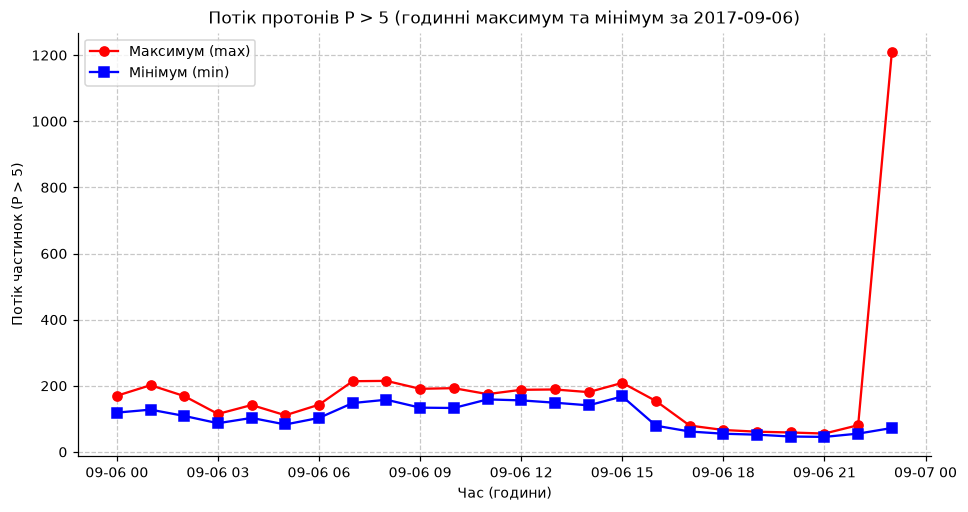

In [15]:
# ВАШ КОД
day_data = A['P > 5'].loc['2017-09-06 00:00:00':'2017-09-06 23:59:59']

hourly_stats = day_data.resample('h').agg(['max', 'min'])

plt.figure(figsize=(10, 5))
plt.plot(hourly_stats.index, hourly_stats['max'], label='Максимум (max)', color='red', marker='o')
plt.plot(hourly_stats.index, hourly_stats['min'], label='Мінімум (min)', color='blue', marker='s')

plt.title('Потік протонів P > 5 (годинні максимум та мінімум за 2017-09-06)')
plt.xlabel('Час (години)')
plt.ylabel('Потік частинок (P > 5)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Червона крива показує максимум руху протонів погодинно, синя - мінімум. Різниця стає суттєвою за рахунок незвичайних подій, як на графіку, де о 23 годині максимум істотно більший за мінімум.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД
if 'ts' in B.columns:
    B = B.set_index('ts')

B = B.drop(columns=['Year', 'Month', 'Date'], errors='ignore')
B_hourly = B.resample('h').ffill() 

if 'ts' in C.columns:
    C = C.set_index('ts')

C = C.drop(columns=['# YR', 'MO', 'DA', 'HH', 'Ind1', 'Ind2'], errors='ignore')

M_outer = pd.concat([A_hourly, B_hourly, C], axis=1, join='outer')
print(f"Розмір M (outer): {M_outer.shape[0]} рядків, {M_outer.shape[1]} колонок")

M_inner = pd.concat([A_hourly, B_hourly, C], axis=1, join='inner')
print(f"Розмір M (inner): {M_inner.shape[0]} рядків, {M_inner.shape[1]} колонок")

M = M_outer

rows_with_nans = M[M.isna().any(axis=1)]

print(f"\nКількість рядків із пропусками: {len(rows_with_nans)}")
display(rows_with_nans)


Розмір M (outer): 601 рядків, 19 колонок
Розмір M (inner): 577 рядків, 19 колонок

Кількість рядків із пропусками: 32


,"(P > 1, mean)","(P > 1, max)","(P > 5, mean)","(P > 5, max)","(P >10, mean)","(P >10, max)","(P >30, mean)","(P >30, max)","(P >50, mean)","(P >50, max)","(P>100, mean)","(P>100, max)","(E>0.8, mean)","(E>0.8, max)","(E>2.0, mean)","(E>2.0, max)",Radio Flux 10.7,SPEED,DENSITY
ts,,,,,,,,,,,,,,,,,,,
2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.1340,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,140.0,NaN,NaN
2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.1340,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,140.0,NaN,NaN
2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.1340,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,140.0,NaN,NaN
2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.1200,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,140.0,NaN,NaN
2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.1100,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,140.0,NaN,NaN
2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.1440,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,140.0,NaN,NaN
2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.1590,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,140.0,NaN,NaN
2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.1660,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,140.0,NaN,NaN
2017-09-21 01:00:00,37.408333,56.30,0.268250,0.375,0.196667,0.335,0.116075,0.255,0.078192,0.1600,0.039483,0.0737,159833.333333,164000.0,38200.000000,41400.0,NaN,453.0,1.9


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Як видно з виводу, outer join з'єднає усі стовпці незалежно від значення(розмір 601 рядок), inner join залишить лише ті стовпці які повністю не пусті(розмір 577 рядків). Залишити обрано outer join, оскільки дані можливо будуть потрібні для наступних обчислень 

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
# ВАШ КОД
bins = [-np.inf, 10, 1000, np.inf]
labels = ['тиха', 'активна', 'дуже активна']
M['група'] = pd.cut(M[('P >10', 'max')], bins=bins, labels=labels, right=False)
M = M.reset_index()
M.head()

,ts,"(P > 1, mean)","(P > 1, max)","(P > 5, mean)","(P > 5, max)","(P >10, mean)","(P >10, max)","(P >30, mean)","(P >30, max)","(P >50, mean)","(P >50, max)","(P>100, mean)","(P>100, max)","(E>0.8, mean)","(E>0.8, max)","(E>2.0, mean)","(E>2.0, max)",Radio Flux 10.7,SPEED,DENSITY,група
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0,82.0,285.0,3.0,тиха
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0,82.0,305.0,3.4,тиха
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0,82.0,309.0,1.7,тиха
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0,82.0,304.0,2.0,тиха
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0,82.0,302.0,2.3,тиха


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє значення: 156.5898
Медіана: 0.6014


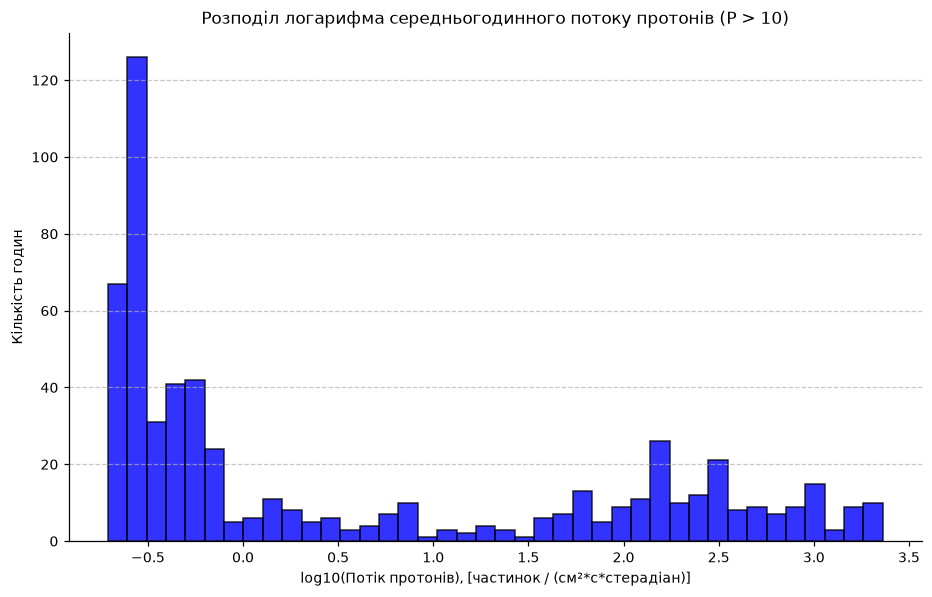

In [19]:
# ВАШ КОД
flux_col = ('P > 5', 'mean')

mean_val = M[flux_col].mean()
median_val = M[flux_col].median()

print(f"Середнє значення: {mean_val:.4f}")
print(f"Медіана: {median_val:.4f}")

plt.figure(figsize=(10, 6))
log_flux = np.log10(M[flux_col].dropna() + 1e-6)

plt.hist(log_flux, bins=40, color='blue', edgecolor='black', alpha=0.8)

plt.title('Розподіл логарифма середньогодинного потоку протонів (P > 10)')
plt.xlabel('log10(Потік протонів), [частинок / (см²*с*стерадіан)]')
plt.ylabel('Кількість годин')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Висновок:**

Оскільки більшість записів потрапляють в проміжок [0, 1], було прийнято рішення використати логарифм за основою 10 для детальнішого представлення графіка. Загалом кількість протонів у потоці рівномірна, з "вибухом" на проміжку [0, 1]  

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

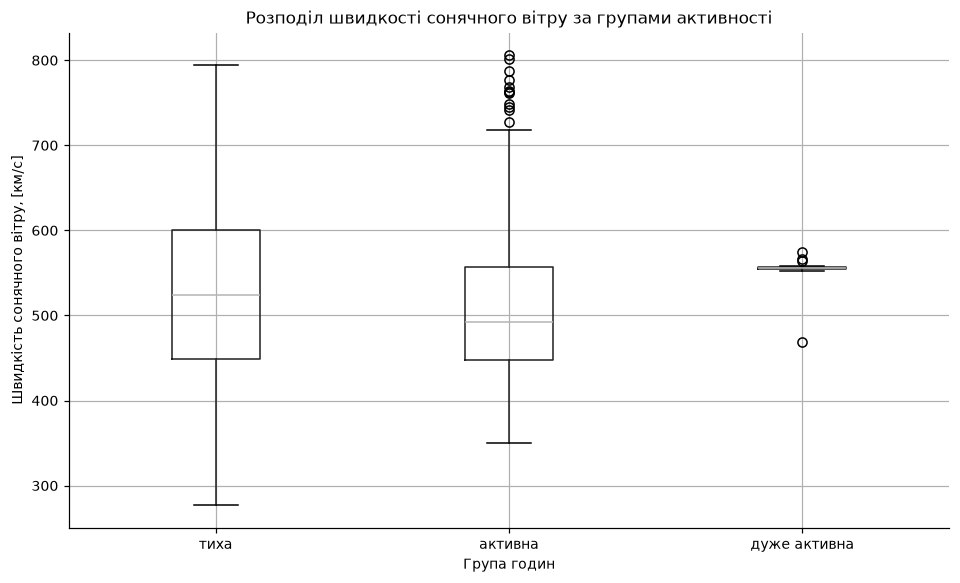

In [20]:
# ВАШ КОД
M.boxplot(column='SPEED', by='група', figsize=(10, 6), grid=True)
plt.suptitle('') 
plt.title('Розподіл швидкості сонячного вітру за групами активності')

plt.xlabel('Група годин')
plt.ylabel('Швидкість сонячного вітру, [км/с]')

plt.show()

**Висновок:**

З графіку видно найбільше значення швидкості коливається в тихій групі, в активній групі все ж менше, проте є чимало записів поза міжквартальним розмахом. Для дуже активної групи характерний короткий діапазон з невеликою кількістю нетипових значень

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

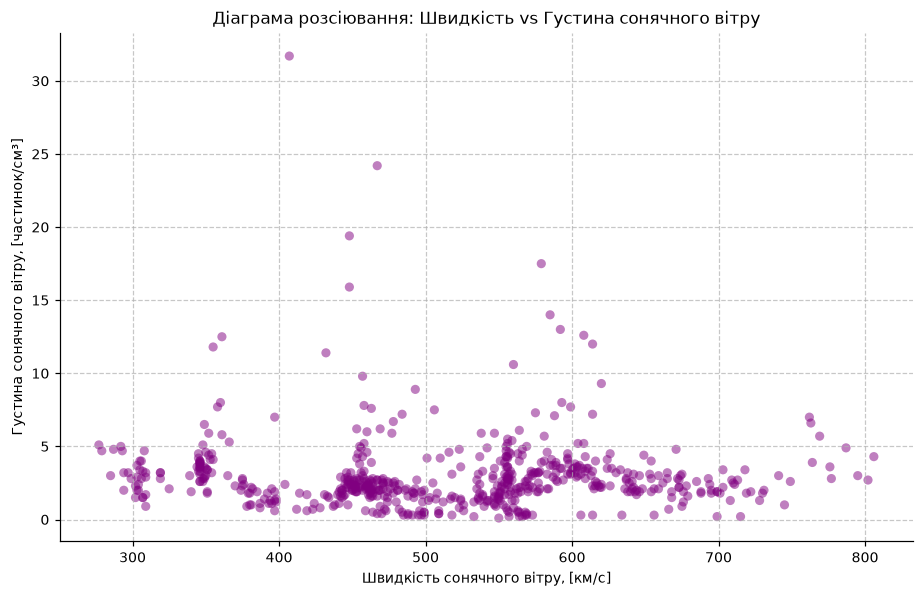

Коефіцієнт кореляції: -0.0391


In [21]:
# ВАШ КОД
plt.figure(figsize=(10, 6))
plt.scatter(M['SPEED'], M['DENSITY'], alpha=0.5, color='purple', edgecolors='none')

plt.title('Діаграма розсіювання: Швидкість vs Густина сонячного вітру')
plt.xlabel('Швидкість сонячного вітру, [км/с]')
plt.ylabel('Густина сонячного вітру, [частинок/см³]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

correlation = M['SPEED'].corr(M['DENSITY'])
print(f"Коефіцієнт кореляції: {correlation:.4f}")

**Висновок:**

Коефіцієнт кореляції -0.0391 свідчить про те що лінійного зв'язку між швидкістю та густиною немає, те саме можна сказати і з графіка. Більшість записів мають різну швидкість, та лежать в межах від 0 до 5 частинок на см^3, без чіткої закономірності.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

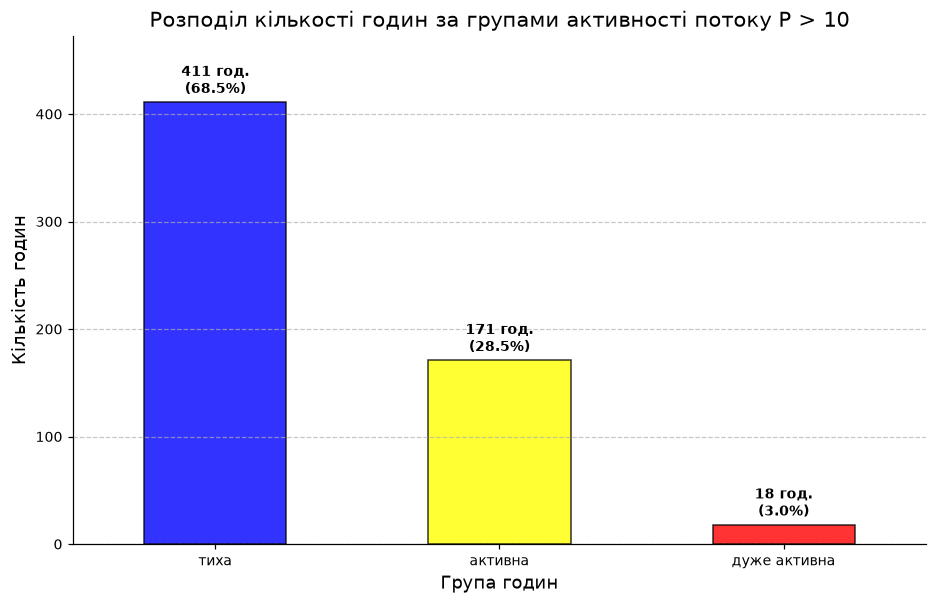

In [22]:
# ВАШ КОД
categories = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts()
percents = M['група'].value_counts(normalize=True) * 100

labels = [f'{int(c)} год.\n({p:.1f}%)' for c, p in zip(counts, percents)]

ax = counts.plot(kind='bar', color=['blue', 'yellow', 'red'], edgecolor='black', alpha=0.8, figsize=(10, 6))
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontweight='bold')

plt.title('Розподіл кількості годин за групами активності потоку P > 10', fontsize=14)
plt.xlabel('Група годин', fontsize=12)
plt.ylabel('Кількість годин', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)

plt.ylim(0, counts.max() * 1.15)

plt.show()

**Висновок:**

За графіком видно що потік P > 10, більшість часу (68 відсотків) перебував у тихій групі, та лише 3 відсотки часу він перебував в дуже активному стані (> 1000 частиць на см²·с·ср). Решта часу (28 відсотків) потік перебував в активній групі.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

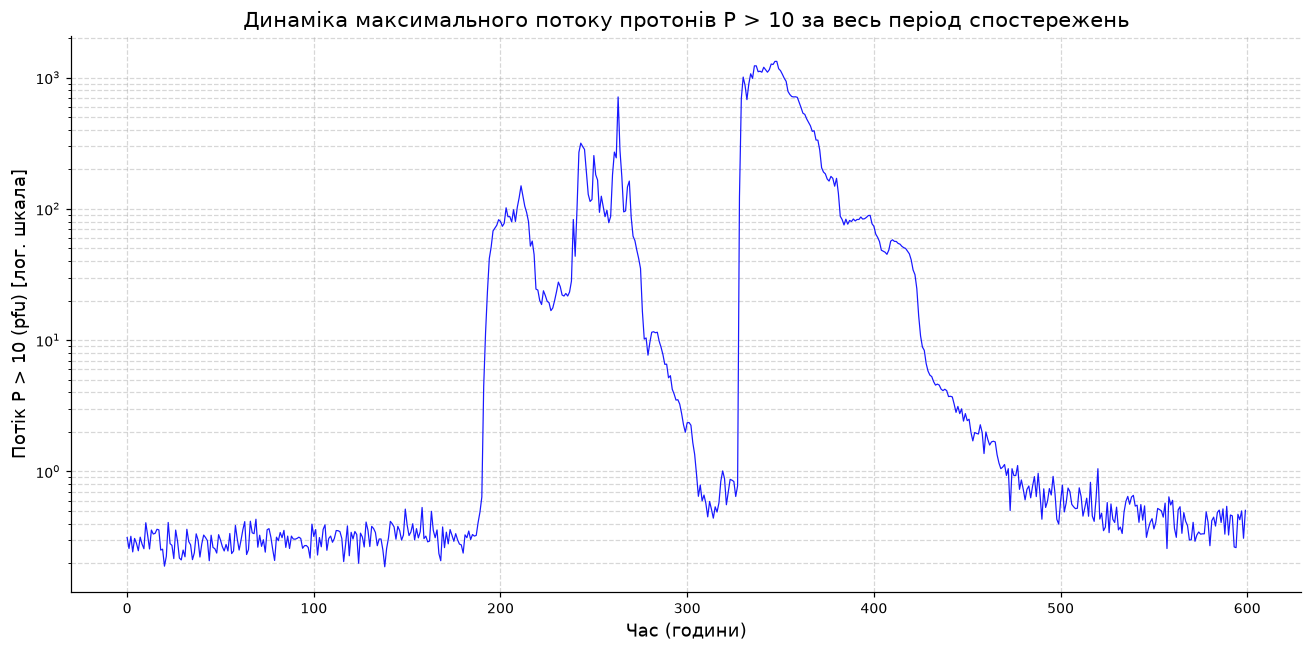

In [23]:
# ВАШ КОД
plt.figure(figsize=(12, 6))

plt.plot(M.index, M[('P >10', 'max')], color='blue', linewidth=0.8, alpha=0.9)
plt.yscale('log')
plt.title('Динаміка максимального потоку протонів P > 10 за весь період спостережень', fontsize=14)
plt.xlabel('Час (години)', fontsize=12)
plt.ylabel('Потік P > 10 (pfu) [лог. шкала]', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Висновок:**

Логарифмічна крива детальніше показує результат. Більшість часу значення від 0 до 1 pfu, з піками та наступними поступовими спадами на позначках 190 годин, 230-240 годин, 320-330 годин.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

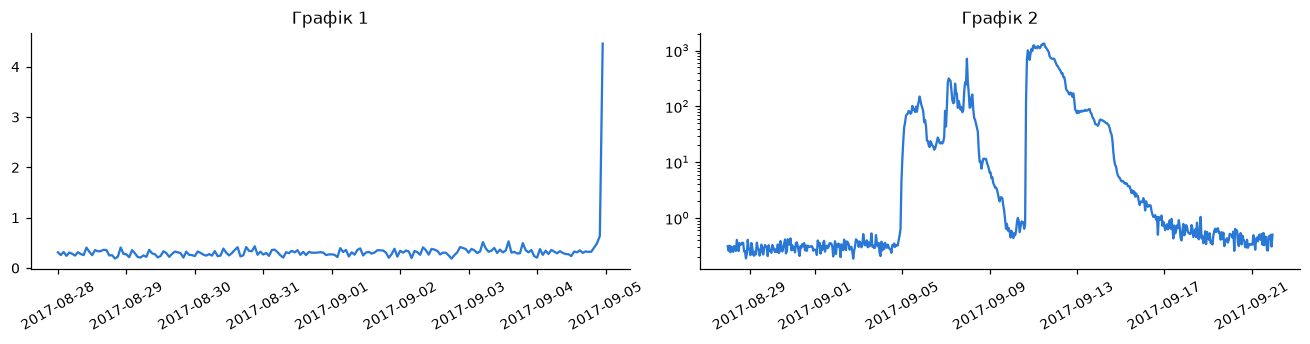

In [24]:
СТОВПЕЦЬ = ('P >10', 'max')   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Погода була стабільною протягом зазначених дат, лише з стрімким підйомом 5 вересня.
2. Висновок з другого графіка: Погода була менш стабільною, з двома чіткими підйомами та відносно повільним спуском.
3. Дві відмінності між ними: перший графік охоплює проміжок часу лише до 5 вересня, другий ж ні (включно з 21 вересня). Також другий графік подано в логарифсічній скалі, що дозволяє чіткіше бачити зміни. 


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

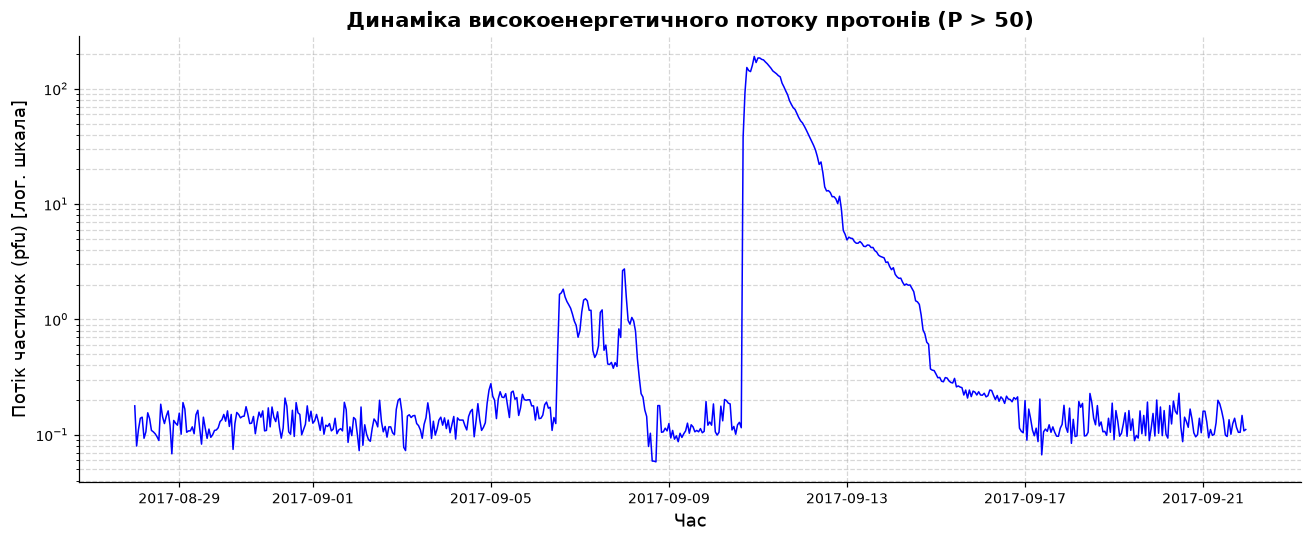

In [25]:
# ВАШ КОД
plt.figure(figsize=(12, 5))

plt.plot(M['ts'], M[('P >50', 'max')], color='blue', linewidth=1, label='Максимум P > 50')

plt.yscale('log')
plt.title('Динаміка високоенергетичного потоку протонів (P > 50)', fontsize=14, fontweight='bold')
plt.xlabel('Час', fontsize=12)
plt.ylabel('Потік частинок (pfu) [лог. шкала]', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Взявши як основу схожий графік для потоку P > 10, я хотів перевірити чи сходяться піки випромінювання в часі. Видно, що основний пік в більшості збігається по часу й динаміці, проте перший дещо слабший й відбувся пізніше.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Потік P > 5 має великий діапазон значень, що свідчить про рідкісні, але значимі події. Максимальне значення 2890 більше ніж в 4500 разів за медіанне 0,632. Див. завдання 3.1 

**Спостереження 2:** Швидкість та густина сонячгного вітру не мають лінійної залежності між собою (коеф. кореляції ~-0,03). Див графік 5.3

**Спостереження 3:** Різні рівні сонячної активності по-різному впливають на швидкості вітру. На діаграмі розмаху видно, що тиха група має найширший діапазон коливань швидкості, тоді як у найактивніших групах діапазон значно вужчий. Див графік 5.2


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
# ВАШ КОД
M.isna().any(axis=1).sum()

np.int64(32)

**Відповідь 7.2:**

Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?
32. Перша та третя таблиці мають пусті записи (-1 як відсутність даних для третьої), також третя таблиця має останній запис за 22 вересня, інші - ні. Друга таблиця мала останній запис за 2017-09-21, що під час розтягування трансформувалось в 2017-09-21 00:00:00, тому інші 23 записи за цей день пусті.


---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Перевірив, чи взято правильні рядки, стовпці при побудові датафреймів, чи використано потрібні стовпці при побудові графіків. Чи згенерований код виконує поставлене завдання'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Кутельмах Євген Петрович
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
Перевірив, чи взято правильні рядки, стовпці при побудові датафреймів, чи використано потрібні стовпці при побудові графіків. Чи згенерований код виконує поставлене завдання
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
